In [1]:
import yfinance as yf

ticker = "BTC-USD"
data = yf.download(ticker, start="2019-01-01", end="2024-12-31", progress=False)['Close']

In [3]:
!pip3 install arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 930.4/930.4 kB 3.0 MB/s eta 0:00:00a 0:00:01


Скачиваем данные BTC-USD за последние 5 лет...


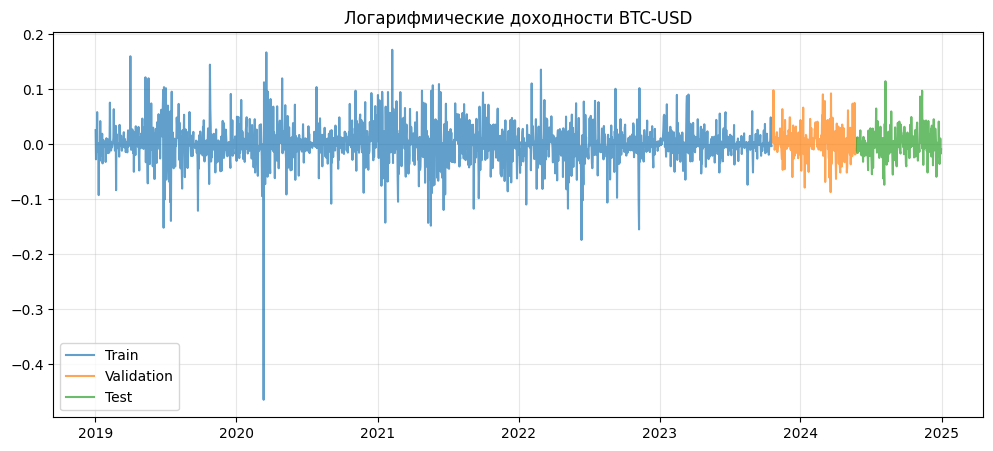

In [20]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from arch import arch_model
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# ==========================
# 1. ЗАГРУЗКА И ПОДГОТОВКА ДАННЫХ (BTC-USD)
# ==========================
print("Скачиваем данные BTC-USD за последние 5 лет...")
ticker = "BTC-USD"
data = yf.download(ticker, start="2019-01-01", end="2024-12-31", progress=False)['Close']

# TODO 1.1: Рассчитайте ежедневные логарифмические доходности.
# Используйте np.log и метод .shift(1). Удалите первое наблюдение (NaN).
returns = np.log(data / data.shift(1))
returns = returns.dropna()

# TODO 1.2: Разделите временной ряд на обучающую (80%), валидационную (10%) и тестовую (10%) выборки.
# Сохраните индексы дат для каждой выборки для последующей визуализации.
split_train = int(0.8 * len(returns))
split_val = int(0.9 * len(returns))
returns_train = returns[:split_train-1]
returns_val = returns[split_train:split_val]
returns_test = returns[split_val:]

# Визуализируем данные
plt.figure(figsize=(12,5))
plt.plot(returns_train.index, returns_train.values, label='Train', alpha=0.7)
plt.plot(returns_val.index, returns_val.values, label='Validation', alpha=0.7)
plt.plot(returns_test.index, returns_test.values, label='Test', alpha=0.7)
plt.title('Логарифмические доходности BTC-USD')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [31]:
# ==========================
# 2. КЛАССИЧЕСКАЯ МОДЕЛЬ GARCH(1,1)
# ==========================
# Обучаем GARCH(1,1) на обучающей выборке
print("\nОбучаем GARCH(1,1)...")
garch_model = arch_model(returns_train * 100, vol='Garch', p=1, q=1, dist='normal')
garch_fitted = garch_model.fit(update_freq=5, disp='off')

# Сохраняем прогнозные волатильности (условные дисперсии)
garch_forecast = garch_fitted.forecast(horizon=100, reindex=False)
garch_forecast.variance


Обучаем GARCH(1,1)...


,h.001,h.002,h.003,h.004,h.005,h.006,h.007,h.008,h.009,h.010,...,h.091,h.092,h.093,h.094,h.095,h.096,h.097,h.098,h.099,h.100
Date,,,,,,,,,,,,,,,,,,,,,
2023-10-18,7.500727,8.003916,8.477633,8.923604,9.343454,9.738712,10.110821,10.461134,10.790929,11.101408,...,16.05426,16.056461,16.058533,16.060484,16.06232,16.064049,16.065677,16.067209,16.068652,16.07001


In [23]:
(returns_train*100).tail()

Ticker,BTC-USD
Date,
2023-10-14,-0.002487
2023-10-15,1.103076
2023-10-16,4.885440
2023-10-17,-0.364340
2023-10-18,-0.308072


In [47]:
from sklearn.model_selection import train_test_split

In [52]:
def create_sequences(data, window):
    X, y = [], []
    for i in range(window, len(data)):
        X.append(data[i-window:i])
        y.append(np.abs(data[i]))   # предсказываем абсолютную доходность (proxy волатильности)
    return np.array(X), np.array(y)

# # Применяем к доходностям тренировочной выборки
x, y = create_sequences(returns.values, 60)
x

array([[[ 0.02565707],
        [-0.02742232],
        [ 0.00545233],
        ...,
        [ 0.00097018],
        [ 0.001244  ],
        [ 0.00125098]],

       [[-0.02742232],
        [ 0.00545233],
        [-0.00325149],
        ...,
        [ 0.001244  ],
        [ 0.00125098],
        [-0.00447101]],

       [[ 0.00545233],
        [-0.00325149],
        [ 0.05844709],
        ...,
        [ 0.00125098],
        [-0.00447101],
        [-0.02250631]],

       ...,

       [[ 0.03944659],
        [-0.00525236],
        [-0.02980622],
        ...,
        [ 0.00629476],
        [-0.03592159],
        [-0.0171688 ]],

       [[-0.00525236],
        [-0.02980622],
        [-0.01049016],
        ...,
        [-0.03592159],
        [-0.0171688 ],
        [ 0.01055391]],

       [[-0.02980622],
        [-0.01049016],
        [-0.00278436],
        ...,
        [-0.0171688 ],
        [ 0.01055391],
        [-0.01731632]]], shape=(2130, 60, 1))

In [63]:
returns.values[:, 0]

array([ 0.02565707, -0.02742232,  0.00545233, ...,  0.01055391,
       -0.01731632, -0.00952899], shape=(2190,))


Обучаем GARCH(1,1)...


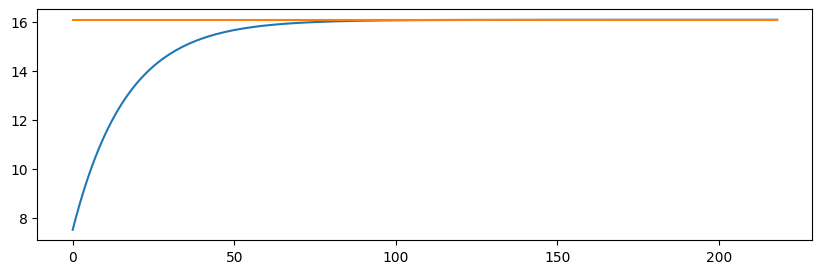

In [68]:
# ==========================
# 2. КЛАССИЧЕСКАЯ МОДЕЛЬ GARCH(1,1)
# ==========================
# Обучаем GARCH(1,1) на обучающей выборке
print("\nОбучаем GARCH(1,1)...")
garch_model = arch_model(returns_train * 100, vol='Garch', p=1, q=1, dist='normal')
garch_fitted = garch_model.fit(update_freq=5, disp='off')

# Сохраняем прогнозные волатильности (условные дисперсии)
garch_forecast = garch_fitted.forecast(horizon=len(returns_test)+len(returns_val), reindex=False)
# TODO 2.1: Извлеките прогнозируемую волатильность (стандартное отклонение) для каждого дня валидационной и тестовой выборок.
# Подсказка: garch_forecast.variance содержит дисперсии, но нужно правильно индексировать.
garch_vol_val = garch_forecast.variance.values[0][:len(returns_val)]
garch_vol_test = garch_forecast.variance.values[0][len(returns_val):]
plt.figure(figsize=(10, 3))
plt.plot(garch_vol_val, label='val')
plt.plot(garch_vol_test, label='test')

# # TODO 2.2: Для тестовой выборки рассчитайте однодневный VaR на уровне доверия 99% и 95%.
# # Формула VaR = -нормальный_квантиль * волатильность (для длинной позиции).
# # Используйте scipy.stats.norm.ppf.
from scipy.stats import norm
VaR_99_garch = -norm.ppf(0.99) * garch_vol_test
VaR_95_garch = -norm.ppf(0.95) * garch_vol_test

# # ==========================
# # 3. ПОДГОТОВКА ДАННЫХ ДЛЯ LSTM/GRU
# # ==========================
# # Для прогнозирования волатильности будем использовать скользящее окно доходностей.
# # Целевая переменная: волатильность (например, стандартное отклонение доходностей за следующие 5 дней) или непосредственно следующая доходность.
# # В данном случае спрогнозируем абсолютное значение будущей доходности как proxy волатильности.

# # TODO 3.1: Создайте последовательности (X, y) для обучения нейросети.
# # Пусть X — это окно из последних N дней исторических доходностей (например, N=60).
# # y — абсолютное значение доходности на следующий день (|r_{t+1}|).
# # Используйте numpy array для формирования X и y.
window_size = 60
def create_sequences(data, window):
    X, y = [], []
    for i in range(window, len(data)):
        X.append(data[i-window:i])
        y.append(np.abs(data[i]))   # предсказываем абсолютную доходность (proxy волатильности)
    return np.array(X), np.array(y)

# # Применяем к доходностям тренировочной выборки
x, y = create_sequences(returns.values[:, 0], window_size)
X_train, X_test, y_train, y_test = train_test_split(x, y, train_size=0.8)
X_test, X_val, y_test, y_val = train_test_split(X_test, y_test, train_size=0.5)


# # TODO 3.2: Нормализуйте входные данные (X) с помощью StandardScaler.
# # Обучите scaler только на тренировочных данных, затем преобразуйте валидационные и тестовые.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.fit_transform(X_val)
X_test_scaled = scaler.fit_transform(X_test)

# # Для LSTM вход должен быть 3D: (samples, timesteps, features). У нас features=1.
X_train_lstm = X_train_scaled.reshape((X_train_scaled.shape[0], X_train_scaled.shape[1], 1))
X_val_lstm = X_val_scaled.reshape((X_val_scaled.shape[0], X_val_scaled.shape[1], 1))
X_test_lstm = X_test_scaled.reshape((X_test_scaled.shape[0], X_test_scaled.shape[1], 1))

# # ==========================
# # 4. ПОСТРОЕНИЕ И ОБУЧЕНИЕ LSTM
# # ==========================
# # TODO 4.1: Создайте модель LSTM с двумя слоями LSTM (по 50 нейронов), Dropout(0.2), затем Dense(1).
# # Используйте активацию 'relu' для LSTM, 'linear' для выходного слоя.
# # Компилируйте с оптимизатором 'adam' и функцией потерь 'mse'.
lstm_model = Sequential([
    LSTM(50, activation='relu'),
    Dropout(0.2),
    LSTM(50, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='linear')
])
lstm_model.compile(optimizer='adam')
# # TODO 4.2: Обучите модель с использованием EarlyStopping (patience=10) на валидационных данных.
# # Установите количество эпох (например, 100) и batch_size=32.
# early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
# history_lstm = # <ВАШ_КОД: lstm_model.fit(...)>

# # TODO 4.3: Сделайте прогноз абсолютной доходности на тестовой выборке.
# pred_abs_return_lstm = # <ВАШ_КОД: model.predict(X_test_lstm)>

# # ==========================
# # 5. ПОСТРОЕНИЕ И ОБУЧЕНИЕ GRU (для сравнения)
# # ==========================
# # TODO 5.1: Создайте аналогичную модель, но с использованием слоев GRU (два слоя по 50 нейронов, Dropout(0.2), Dense(1)).
# gru_model = # <ВАШ_КОД>

# # TODO 5.2: Скомпилируйте и обучите GRU с теми же параметрами.
# history_gru = # <ВАШ_КОД: gru_model.fit(...)>

# # TODO 5.3: Получите прогнозы на тесте.
# pred_abs_return_gru = # <ВАШ_КОД>

# # ==========================
# # 6. РАСЧЕТ VaR ДЛЯ НЕЙРОСЕТЕВЫХ МОДЕЛЕЙ
# # ==========================
# # Нейросеть предсказывает абсолютную доходность. Используем её как прогноз волатильности (при условии нулевого среднего).
# # TODO 6.1: Для тестовой выборки рассчитайте VaR_99 и VaR_95 для LSTM и GRU.
# # Формула: VaR = - norm.ppf(confidence) * predicted_volatility (где predicted_volatility = pred_abs_return).
# VaR_99_lstm = # <ВАШ_КОД>
# VaR_95_lstm = # <ВАШ_КОД>
# VaR_99_gru = # <ВАШ_КОД>
# VaR_95_gru = # <ВАШ_КОД>

# # ==========================
# # 7. БЭКТЕСТИНГ VaR (КОЛИЧЕСТВО ПРОБИЙ)
# # ==========================
# # Для каждой модели посчитаем количество дней, когда фактический убыток (отрицательная доходность) превышал VaR.
# # Фактический убыток для длинной позиции = -return_t (если return_t отрицательный, то убыток положительный).
# actual_loss = -returns_test.values[window_size:]  # обрезаем до длины прогнозов

# # TODO 7.1: Реализуйте функцию нарушения VaR (exceedance).
# # Вход: массив VaR (положительные числа), массив фактических убытков. Выход: доля нарушений.
# def violation_ratio(var_values, actual_losses):
#     # <ВАШ_КОД>

# # Для GARCH (убедитесь, что длины совпадают)
# actual_loss_garch = actual_loss  # так как GARCH дал прогнозы на тест той же длины

# print("=== Доля нарушений VaR (тестовая выборка) ===")
# print(f"GARCH(1,1) 99%: {violation_ratio(VaR_99_garch, actual_loss_garch):.4f} (ожидалось 0.01)")
# print(f"GARCH(1,1) 95%: {violation_ratio(VaR_95_garch, actual_loss_garch):.4f} (ожидалось 0.05)")
# print(f"LSTM 99%: {violation_ratio(VaR_99_lstm.flatten(), actual_loss):.4f}")
# print(f"LSTM 95%: {violation_ratio(VaR_95_lstm.flatten(), actual_loss):.4f}")
# print(f"GRU 99%: {violation_ratio(VaR_99_gru.flatten(), actual_loss):.4f}")
# print(f"GRU 95%: {violation_ratio(VaR_95_gru.flatten(), actual_loss):.4f}")

# # ==========================
# # 8. ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ
# # ==========================
# # График 1: Сравнение предсказанной волатильности (абс. доходности) на тесте
# plt.figure(figsize=(14,5))
# plt.plot(returns_test.index[window_size:], y_test, label='Actual |return|', alpha=0.6)
# plt.plot(returns_test.index[window_size:], pred_abs_return_lstm, label='LSTM predicted', alpha=0.8)
# plt.plot(returns_test.index[window_size:], pred_abs_return_gru, label='GRU predicted', alpha=0.8)
# plt.title('Прогноз абсолютной доходности (proxy волатильности)')
# plt.legend()
# plt.grid(alpha=0.3)
# plt.show()

# # График 2: Сравнение VaR 99% на тесте (выбрать одну модель для наглядности)
# plt.figure(figsize=(14,5))
# plt.plot(returns_test.index[window_size:], returns_test.values[window_size:], label='Доходность', alpha=0.6)
# plt.plot(returns_test.index[window_size:], -VaR_99_garch, label='GARCH VaR 99%', linestyle='--', color='red')
# plt.plot(returns_test.index[window_size:], -VaR_99_lstm.flatten(), label='LSTM VaR 99%', linestyle='--', color='blue')
# plt.fill_between(returns_test.index[window_size:], -VaR_99_garch, -VaR_99_lstm.flatten(), alpha=0.2)
# plt.title('Сравнение VaR 99%: GARCH vs LSTM')
# plt.legend()
# plt.grid(alpha=0.3)
# plt.show()

# # График 3: Кумулятивные нарушения VaR (кумулятивная сумма превышений)
# # TODO 8.1: Постройте ступенчатый график кумулятивного количества нарушений для каждой модели.
# # Это поможет увидеть, не сгруппированы ли нарушения (что плохо для модели).

In [67]:
X_train_scaled.reshape((X_train_scaled.shape[0], X_train_scaled.shape[1], 1)).shape

(1704, 60, 1)

In [40]:
print(garch_fitted.params)
print("alpha + beta =", garch_fitted.params['alpha[1]'] + garch_fitted.params['beta[1]'])

mu          0.175800
omega       0.942513
alpha[1]    0.123102
beta[1]     0.818328
Name: params, dtype: float64
alpha + beta = 0.9414291211231128


In [43]:
from scipy.stats import norm
norm.ppf(0.95)

np.float64(1.644853626951472)

In [45]:
-norm.ppf(0.95) * garch_vol_val

array([-12.33759864, -13.16527077, -13.94446541, -14.67802194,
       -15.36861342, -16.01875635, -16.63081984, -17.20703423,
       -17.74949924, -18.26019159, -18.74097225, -19.19359315,
       -19.61970366, -20.0208565 , -20.39851346, -20.75405072,
       -21.08876386, -21.40387255, -21.70052505, -21.97980235,
       -22.24272213, -22.49024247, -22.72326533, -22.94263983,
       -23.14916538, -23.34359454, -23.52663582, -23.69895621,
       -23.86118364, -24.01390926, -24.15768962, -24.29304863,
       -24.42047955, -24.54044672, -24.65338731, -24.75971288,
       -24.85981086, -24.95404601, -25.04276173, -25.12628129,
       -25.20490904, -25.27893149, -25.34861838, -25.41422364,
       -25.47598635, -25.53413157, -25.58887117, -25.64040462,
       -25.68891971, -25.73459323, -25.77759161, -25.81807154,
       -25.85618052, -25.89205743, -25.92583299, -25.95763029,
       -25.9875652 , -26.01574679, -26.04227776, -26.06725479,
       -26.09076889, -26.11290575, -26.13374604, -26.15